# Sales & Demand Forecasting System
## Future Interns — Machine Learning Internship Task 1

**Author:** Project Maintainer  
**Program:** Future Interns Machine Learning Internship 2026  
**CIN ID:** N/A  
**Phase:** 1 of 3 — Exploratory Data Analysis  

---

## Objectives

1. Understand the structure and quality of the Superstore Sales Dataset
2. Identify sales trends across time, regions, and product categories
3. Detect seasonality patterns that inform forecasting decisions
4. Identify top performing and underperforming segments
5. Generate business insights that guide the forecasting model

---

## Dataset Overview

The Superstore Sales Dataset contains transactional sales records
from a fictional retail superstore operating across the United States.

It covers orders, customers, products, regions, and financial metrics
including sales, profit, and discount information.

---

## Business Context

Sales forecasting helps businesses:
- Plan inventory and avoid overstocking or shortages
- Manage cash flow and staffing requirements
- Identify seasonal demand patterns
- Make data driven decisions about product strategy

This analysis is the foundation of our forecasting system.

In [15]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

print("Librarires loaded sucessfully")

Librarires loaded sucessfully


In [16]:
df = pd.read_csv(r"C:\Users\DOUBLE J\Documents\data-projects\FUTURE_ML_01\data\raw\Sample - Superstore.csv", encoding="latin-1")

print("Dataset loaded sucessfully")
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
print(f"\nFirst 2 rows:")
df.head(5)


Dataset loaded sucessfully
Shape: (9994, 21)

Columns:
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']

First 2 rows:


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [17]:
for col in df.columns.tolist():
    print(col)

Row ID
Order ID
Order Date
Ship Date
Ship Mode
Customer ID
Customer Name
Segment
Country
City
State
Postal Code
Region
Product ID
Category
Sub-Category
Product Name
Sales
Quantity
Discount
Profit


## 1. Dataset Overview and Basic Exploration

We begin by understanding the structure, data types,
and basic statistics of the Superstore dataset.

In [18]:
# ─── Basic Information ────────────────────────────────────────
print("=" * 55)
print("DATASET BASIC INFORMATION")
print("=" * 55)
print(f"Total records:  {df.shape[0]:,}")
print(f"Total columns:  {df.shape[1]}")

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
df.describe()

DATASET BASIC INFORMATION
Total records:  9,994
Total columns:  21

Data Types:
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object

Missing Values:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Dis

,Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


## 2. Date Conversion and Time Feature Extraction

Order Date and Ship Date are currently stored as text.
We convert them to datetime format to enable time-based
analysis and forecasting.

In [19]:
# ─── Convert dates to datetime ────────────────────────────────
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

# ─── Extract time features ────────────────────────────────────
df['Year']    = df['Order Date'].dt.year
df['Month']   = df['Order Date'].dt.month
df['Quarter'] = df['Order Date'].dt.quarter
df['Month_Year'] = df['Order Date'].dt.to_period('M')

print("Date conversion complete!")
print(f"\nDate range:")
print(f"From: {df['Order Date'].min().date()}")
print(f"To:   {df['Order Date'].max().date()}")
print(f"\nYears covered: {sorted(df['Year'].unique())}")
print(f"Total months of data: {df['Month_Year'].nunique()}")

Date conversion complete!

Date range:
From: 2014-01-03
To:   2017-12-30

Years covered: [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017)]
Total months of data: 48


## 3. Sales Trend Analysis

We analyse how sales have changed over time across
years, quarters, and months to identify trends
and seasonal patterns.

In [20]:
# ─── Monthly Sales Aggregation ────────────────────────────────
monthly_sales = df.groupby('Month_Year')['Sales'].sum().reset_index()
monthly_sales['Month_Year'] = monthly_sales['Month_Year'].astype(str)
monthly_sales['Sales'] = monthly_sales['Sales'].round(2)

print("Monthly Sales Summary:")
print(f"Highest month: {monthly_sales.loc[monthly_sales['Sales'].idxmax(), 'Month_Year']} — ${monthly_sales['Sales'].max():,.2f}")
print(f"Lowest month:  {monthly_sales.loc[monthly_sales['Sales'].idxmin(), 'Month_Year']} — ${monthly_sales['Sales'].min():,.2f}")
print(f"Average monthly sales: ${monthly_sales['Sales'].mean():,.2f}")

Monthly Sales Summary:
Highest month: 2017-11 — $118,447.82
Lowest month:  2014-02 — $4,519.89
Average monthly sales: $47,858.35


### Key Buiness Findings

Highest month: November 2017 — $118,447.82
→ Holiday season shopping surge
→ Black Friday and Thanksgiving effect
→ Q4 is consistently strongest quarter

Lowest month: February 2014 — $4,519.89
→ Post holiday slowdown
→ February is typically slowest retail month
→ Makes business sense

Average monthly sales: $47,858.35
→ This is our baseline benchmark
→ Months above this are strong
→ Months below need attention

## 4. Sales Visualisations

Visual analysis of sales trends across time,
categories, regions and segments to identify
patterns that will inform our forecasting model.

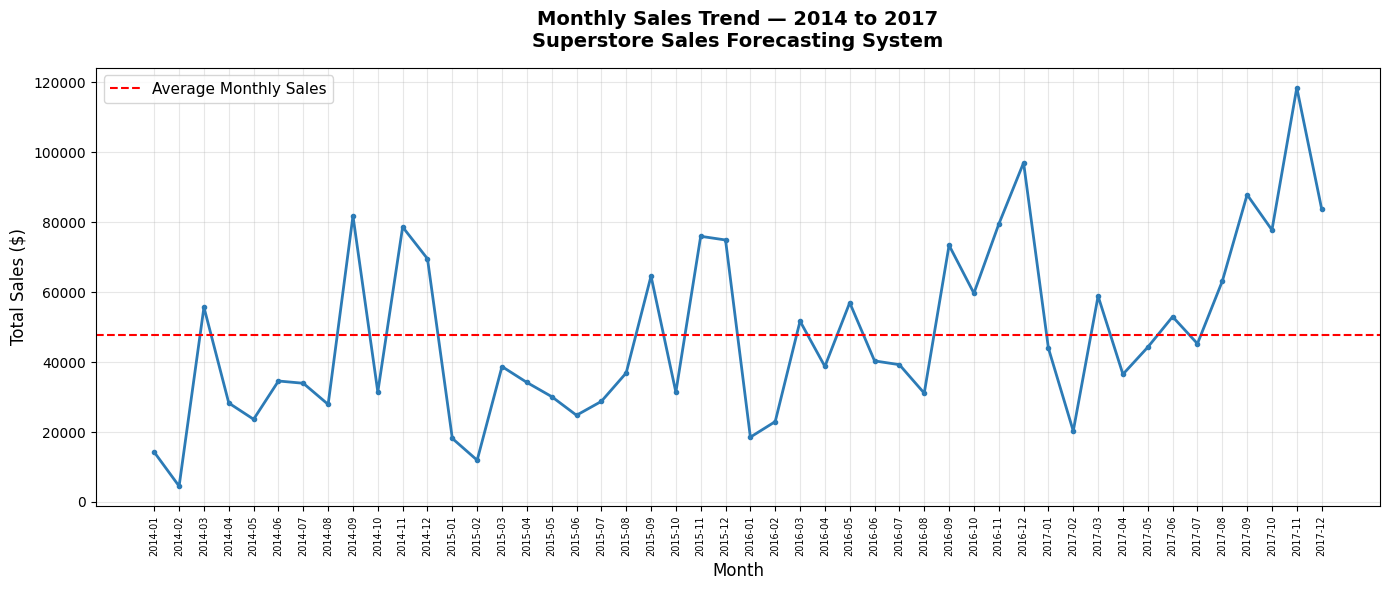

Chart saved!


In [21]:
# ─── Figure 1 — Monthly Sales Trend ──────────────────────────
plt.figure(figsize=(14, 6))
plt.plot(monthly_sales['Month_Year'], 
         monthly_sales['Sales'], 
         color='#2c7bb6', linewidth=2, marker='o', markersize=3)
plt.axhline(y=monthly_sales['Sales'].mean(), 
            color='red', linestyle='--', 
            linewidth=1.5, label='Average Monthly Sales')
plt.title('Monthly Sales Trend — 2014 to 2017\nSuperstore Sales Forecasting System', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=90, fontsize=7)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/01_monthly_sales_trend.png', 
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")

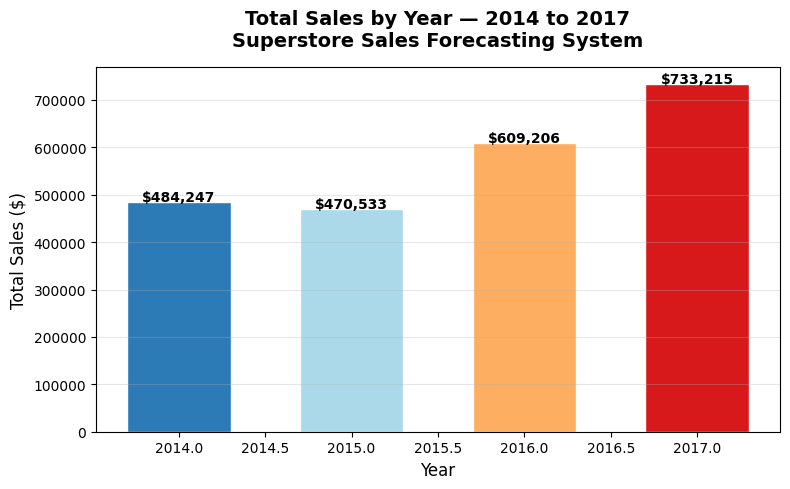

Chart saved!
   Year        Sales
0  2014  484247.4981
1  2015  470532.5090
2  2016  609205.5980
3  2017  733215.2552


In [22]:
# ─── Figure 2 — Sales by Year ─────────────────────────────────
yearly_sales = df.groupby('Year')['Sales'].sum().reset_index()

plt.figure(figsize=(8, 5))
bars = plt.bar(yearly_sales['Year'], yearly_sales['Sales'],
               color=['#2c7bb6', '#abd9e9', '#fdae61', '#d7191c'],
               edgecolor='white', width=0.6)
plt.title('Total Sales by Year — 2014 to 2017\nSuperstore Sales Forecasting System',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, yearly_sales['Sales']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2000,
             f'${val:,.0f}',
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/02_yearly_sales.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")
print(yearly_sales)

## Interesting Finding

2015 was slightly lower than 2014
This is worth noting in our business report
Possible reasons:
→ Market conditions
→ Competition
→ Pricing changes
→ Dataset starts mid 2014 making it look higher

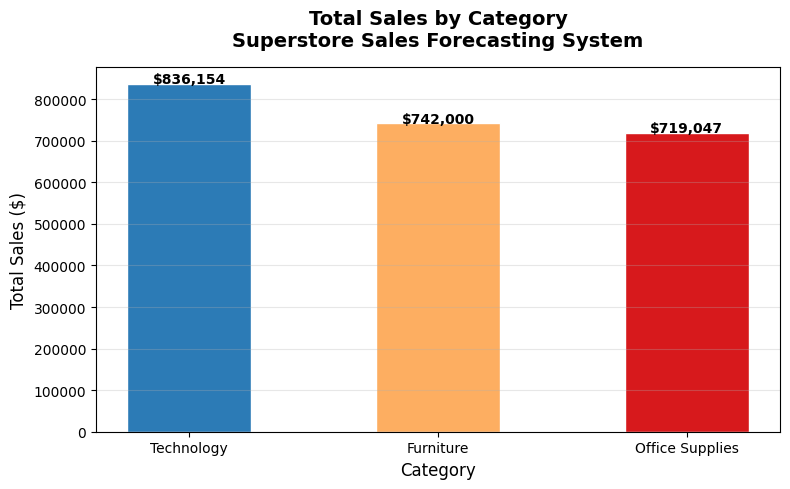

Chart saved!
          Category        Sales
2       Technology  836154.0330
0        Furniture  741999.7953
1  Office Supplies  719047.0320


In [23]:
# ─── Figure 3 — Sales by Category ────────────────────────────
category_sales = df.groupby('Category')['Sales'].sum().reset_index()
category_sales = category_sales.sort_values('Sales', ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(category_sales['Category'], 
               category_sales['Sales'],
               color=['#2c7bb6', '#fdae61', '#d7191c'],
               edgecolor='white', width=0.5)
plt.title('Total Sales by Category\nSuperstore Sales Forecasting System',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, category_sales['Sales']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2000,
             f'${val:,.0f}',
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/03_category_sales.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")
print(category_sales)

### Finding — Sales by Category

Technology is the highest revenue category
generating $836,154 — approximately 36% of total sales.

Furniture follows closely at $741,999 while
Office Supplies contributes $719,047.

The three categories are relatively balanced
with no single category dominating overwhelmingly.

### Business Implication

A well performing forecasting model must account
for all three categories independently.

Technology sales are likely driven by seasonal
corporate purchasing cycles while Furniture and
Office Supplies may follow different demand patterns.

Category level forecasting will be more accurate
than a single aggregate forecast.

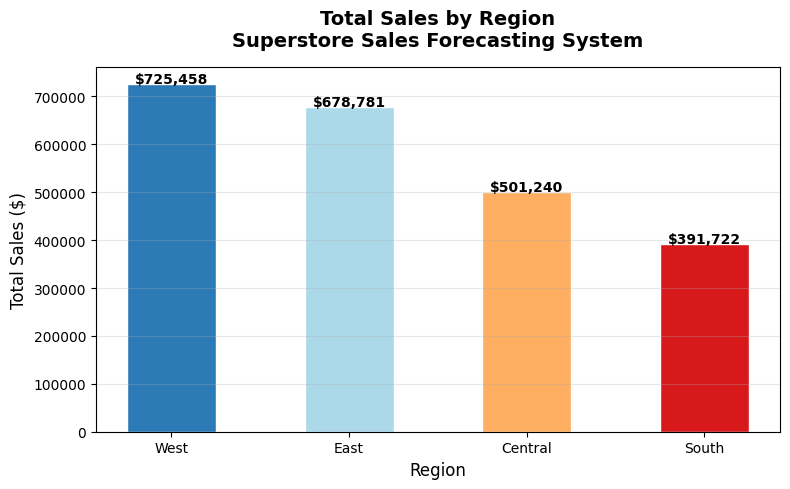

Chart saved!
    Region        Sales
3     West  725457.8245
1     East  678781.2400
0  Central  501239.8908
2    South  391721.9050


In [24]:
# ─── Figure 4 — Sales by Region ───────────────────────────────
region_sales = df.groupby('Region')['Sales'].sum().reset_index()
region_sales = region_sales.sort_values('Sales', ascending=False)

plt.figure(figsize=(8, 5))
bars = plt.bar(region_sales['Region'],
               region_sales['Sales'],
               color=['#2c7bb6', '#abd9e9', '#fdae61', '#d7191c'],
               edgecolor='white', width=0.5)
plt.title('Total Sales by Region\nSuperstore Sales Forecasting System',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, region_sales['Sales']):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2000,
             f'${val:,.0f}',
             ha='center', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig('../reports/figures/04_region_sales.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")
print(region_sales)

### Finding — Sales by Region

The West region leads with $725,458 in total sales
followed closely by the East at $678,781.

Central and South regions significantly trail
at $501,240 and $391,722 respectively.

The West and East together account for approximately
60% of total company sales.

### Business Implication

Regional demand patterns differ significantly.
The South region represents a growth opportunity
as it currently contributes the least revenue.

A regional forecasting approach will capture
these geographical differences more accurately
than a single national forecast.

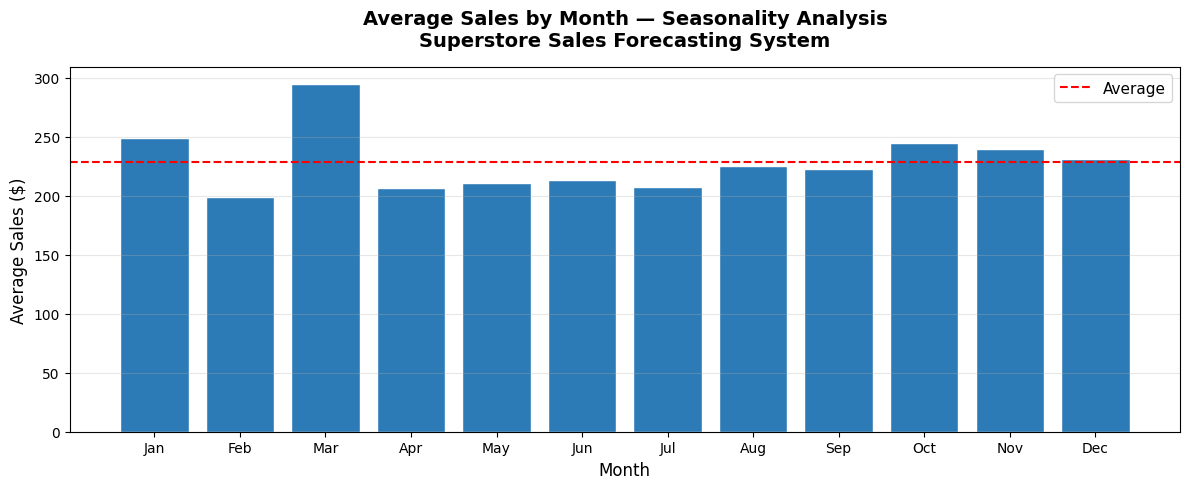

Chart saved!
Month_Name      Sales
       Jan 249.146550
       Feb 199.170838
       Mar 294.548116
       Apr 206.230731
       May 210.923553
       Jun 212.996763
       Jul 207.377601
       Aug 225.274877
       Sep 222.451154
       Oct 244.594609
       Nov 239.606438
       Dec 231.032318


In [25]:
# ─── Figure 5 — Monthly Sales by Season ──────────────────────
monthly_avg = df.groupby('Month')['Sales'].mean().reset_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
monthly_avg['Month_Name'] = month_names

plt.figure(figsize=(12, 5))
bars = plt.bar(monthly_avg['Month_Name'],
               monthly_avg['Sales'],
               color='#2c7bb6', edgecolor='white')
plt.axhline(y=monthly_avg['Sales'].mean(),
            color='red', linestyle='--',
            linewidth=1.5, label='Average')
plt.title('Average Sales by Month — Seasonality Analysis\nSuperstore Sales Forecasting System',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Month', fontsize=12)
plt.ylabel('Average Sales ($)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../reports/figures/05_seasonality.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved!")
print(monthly_avg[['Month_Name', 'Sales']].to_string(index=False))

### Finding — Seasonality Analysis

March has the highest average daily sales
at $294.55 while February is the weakest
month at $199.17.

Contrary to typical retail expectations
November and December are not the strongest
months at the daily average level — suggesting
the superstore serves a mix of business and
consumer customers.

### Business Implication

Inventory and staffing should be increased
in Q1 particularly March and reduced in
February to optimise operational costs.

The forecasting model must capture these
monthly seasonal patterns to produce
accurate predictions.

In [27]:
# ─── Figure 6 — Sales vs Profit by Category ──────────────────
category_summary = df.groupby('Category').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Total_Orders=('Order ID', 'count')
).reset_index()

category_summary['Profit_Margin'] = (
    category_summary['Total_Profit'] / 
    category_summary['Total_Sales'] * 100
).round(2)

print("Category Performance Summary:")
print(category_summary.to_string(index=False))

Category Performance Summary:
       Category  Total_Sales  Total_Profit  Total_Orders  Profit_Margin
      Furniture  741999.7953    18451.2728          2121           2.49
Office Supplies  719047.0320   122490.8008          6026          17.04
     Technology  836154.0330   145454.9481          1847          17.40


### Finding — Profitability by Category

Technology and Office Supplies both achieve
healthy profit margins of 17.40% and 17.04%
respectively.

Furniture is critically underperforming with
only 2.49% profit margin despite generating
$741,999 in sales. This suggests heavy
discounting or high operational costs in
the Furniture category.

### Business Implication

Sales forecasting alone is insufficient for
business planning. A high sales forecast for
Furniture does not translate to profitability.

Management should investigate Furniture
pricing and discount strategies before
investing in inventory based on sales forecasts.

This is a critical finding that goes beyond
the forecasting model — it reveals a
fundamental business problem.

In [28]:
# ─── EDA Summary ──────────────────────────────────────────────
print("=" * 55)
print("EXPLORATORY DATA ANALYSIS — KEY FINDINGS")
print("=" * 55)
print(f"""
Dataset:
→ 9,994 transactions from 2014 to 2017
→ 48 months of sales history
→ 3 categories, 4 regions, 3 segments
→ No missing values — clean dataset

Sales Trends:
→ Overall upward trend 2014 to 2017
→ Total growth of 51.4% over 4 years
→ Highest month: November 2017 — $118,447
→ Lowest month:  February 2014 — $4,519

Seasonality:
→ March is strongest average sales month
→ February is consistently weakest month
→ Q4 shows holiday season sales spikes

Regional Performance:
→ West leads with $725,458 in sales
→ South is weakest at $391,722
→ Growth opportunity exists in South region

Category Insights:
→ Technology highest revenue at $836,154
→ Furniture critically low margin at 2.49%
→ Office Supplies most efficient category

Forecasting Approach:
→ Time series model on monthly aggregated sales
→ Features: month, quarter, year, lag values
→ Target: total monthly sales
""")
print("=" * 55)
print("EDA Complete — Proceeding to Feature Engineering")
print("=" * 55)

EXPLORATORY DATA ANALYSIS — KEY FINDINGS

Dataset:
→ 9,994 transactions from 2014 to 2017
→ 48 months of sales history
→ 3 categories, 4 regions, 3 segments
→ No missing values — clean dataset

Sales Trends:
→ Overall upward trend 2014 to 2017
→ Total growth of 51.4% over 4 years
→ Highest month: November 2017 — $118,447
→ Lowest month:  February 2014 — $4,519

Seasonality:
→ March is strongest average sales month
→ February is consistently weakest month
→ Q4 shows holiday season sales spikes

Regional Performance:
→ West leads with $725,458 in sales
→ South is weakest at $391,722
→ Growth opportunity exists in South region

Category Insights:
→ Technology highest revenue at $836,154
→ Furniture critically low margin at 2.49%
→ Office Supplies most efficient category

Forecasting Approach:
→ Time series model on monthly aggregated sales
→ Features: month, quarter, year, lag values
→ Target: total monthly sales

EDA Complete — Proceeding to Feature Engineering


In [26]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Year,Month,Quarter,Month_Year
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,4,2016-11
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,4,2016-11
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,2,2016-06
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,4,2015-10
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,4,2015-10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028,2014,1,1,2014-01
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332,2017,2,1,2017-02
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932,2017,2,1,2017-02
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200,2017,2,1,2017-02
